# Interest Rates and Housing Market Activity in the United States

## Research Question:
What is the relationship between interest rates and housing market activity in the United States?

Interest rates play an important role in the U.S. economy because they influence borrowing costs for consumers and businesses. In the housing market, higher interest rates can increase the cost of mortgages and other forms of financing, which may affect housing demand and the construction of new homes. Because the United States is currently experiencing a housing crisis, understanding this relationship is important for policymaking and overall economic well being.

This project explores how interest rates are associated with changes in housing market activity using data from the Federal Reserve Economic Data database (FRED). The data consists of monthly observations from March 2001 through March 2026 and represents national U.S. economic activity. Three datasets were selected for this analysis: Housing Starts, Building Permits, and the Federal Funds Rate. Housing starts and building permits are used as measures of housing market activity, while the Federal Funds Rate represents the measure of interest rates. Through exploratory data analysis, visualizations, and statistical analysis, this project will examine how these variables have changed over time and investigates the patterns and relationships that exist between them.

## Hypothesis:
H0: There is no relationship between interest rates and housing market activity.

H1: There is a relationship between interest rates and housing market activity.


## Importing Libraries

The following Python libraries were used for data cleaning, visualization, and exploratory data analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Loading the Data

The datasets were downloaded from the FRED database. Each dataset contains monthly observations for a different economic indicator related to interest rates or housing market activity

The three variables are:

Federal Funds Rate: Used as the interest rate measure
Housing Starts: Used as a measure of current housing construction activity
Building Permits: Used as a  measure of housing market activity

In [2]:
fed = pd.read_csv(r"C:\Users\Ashok\Downloads\final project\FEDFUNDS.csv")

hous = pd.read_csv(r"C:\Users\Ashok\Downloads\final project\HOUST (1).csv")

permit = pd.read_csv(r"C:\Users\Ashok\Downloads\final project\PERMIT.csv")

## Previewing the Raw Data

Before cleaning and merging the datasets, the first few rows of each dataset were examined to better understand their structure and variables.

In [3]:
print(fed.head())
print(hous.head())
print(permit.head())

  observation_date  FEDFUNDS
0       2000-03-01      5.85
1       2000-04-01      6.02
2       2000-05-01      6.27
3       2000-06-01      6.53
4       2000-07-01      6.54
  observation_date  HOUST
0       2000-01-01   1636
1       2000-02-01   1737
2       2000-03-01   1604
3       2000-04-01   1626
4       2000-05-01   1575
  observation_date  PERMIT
0       2000-01-01    1727
1       2000-02-01    1692
2       2000-03-01    1651
3       2000-04-01    1597
4       2000-05-01    1543


## Cleaning and Data Prep

To simplify our analysis, the variable names were changed and date columns were converted into a datetime format. The datasets were then combined by date so that each row represents one monthly observation.

In [4]:
fed = fed.rename(columns={"observation_date": "date","FEDFUNDS": "rate"})

hous = hous.rename(columns={"observation_date": "date","HOUST": "housing"})

permit = permit.rename(columns={"observation_date": "date","PERMIT": "permits"})

In [5]:
fed["date"] = pd.to_datetime(fed["date"])
hous["date"] = pd.to_datetime(hous["date"])
permit["date"] = pd.to_datetime(permit["date"])

In [6]:
df = pd.merge(hous, fed, on="date")
df = pd.merge(df, permit, on="date")

df.head()

,date,housing,rate,permits
0,2000-03-01,1604,5.85,1651
1,2000-04-01,1626,6.02,1597
2,2000-05-01,1575,6.27,1543
3,2000-06-01,1559,6.53,1572
4,2000-07-01,1463,6.54,1542


## Dataset Overview

After merging the datasets, the final dataframe contains monthly observations for housing starts, building permits, and the Federal Funds Rate.

In [7]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 313 entries, 0 to 312
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     313 non-null    datetime64[us]
 1   housing  313 non-null    int64         
 2   rate     313 non-null    float64       
 3   permits  313 non-null    int64         
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 9.9 KB
None
                             date      housing        rate      permits
count                         313   313.000000  313.000000   313.000000
mean   2013-03-01 19:37:45.814696  1306.386581    2.000543  1367.067093
min           2000-03-01 00:00:00   478.000000    0.050000   513.000000
25%           2006-09-01 00:00:00  1023.000000    0.150000  1072.000000
50%           2013-03-01 00:00:00  1324.000000    1.260000  1401.000000
75%           2019-09-01 00:00:00  1592.000000    3.880000  1659.000000
max           2026-03-01 00:00:00  2273.000000    6.540000 

The merged dataset contains 313 monthly observations from March 2000 through March 2026. The Summary stats shows variation in both housing market activity and interest rates over time.

The housing starts ranged from 478 to 2273, while building permits ranged from 513 to 2263. The Federal Funds Rate ranged from 0.05% to 6.54%, which indicates major shifts in economic conditions across our sample period.

In [8]:
df.isnull().sum()

date       0
housing    0
rate       0
permits    0
dtype: int64

The dataset contains no missing values.

## Variable Distribution

Before examining relationships between variables, the distributions of interest rates, housing starts, and building permits were explored.

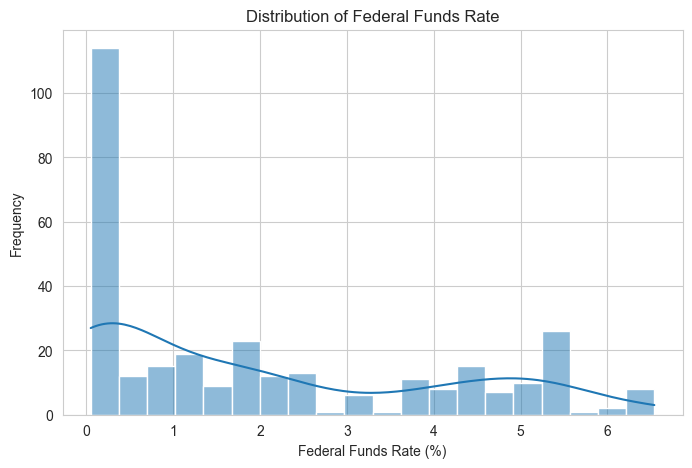

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["rate"], bins=20, kde=True)

plt.title("Distribution of Federal Funds Rate")
plt.xlabel("Federal Funds Rate (%)")
plt.ylabel("Frequency")

plt.show()

The distribution of the Federal Funds Rate is concentrated at lower interest rate levels, with a large amount of observations near 0% to 1%. This reflects the extended periods of low interest rates in response to major economic issue such as the 2008 financial crisis and the COVID-19 pandemic. The distribution also shows that higher interest rates occurred less frequently throughout our sample period. Overall, the Fed Funds Rate is not evenly distributed over time and is extremely variable across different economic events.

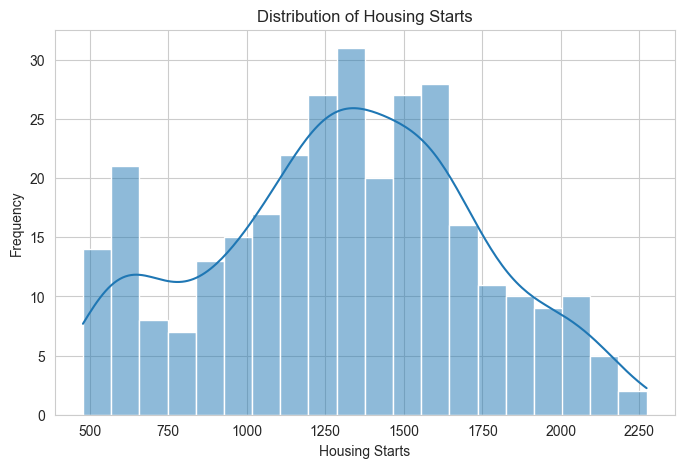

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["housing"], bins=20, kde=True)

plt.title("Distribution of Housing Starts")
plt.xlabel("Housing Starts")
plt.ylabel("Frequency")

plt.show()

The distribution of housing starts is moderately spread across the sample period, with most observations concentrated between about 1,000 and 1,700 housing starts. The distribution peaks around 1,300 to 1,500 housing starts. 

Lower levels of housing starts occurred less frequently and may reflect periods of economic recession, with less people buying new houses. Higher levels of housing starts were also relatively uncommon, and distinctly less frequent than the Lower levels. This suggests that extreme levels of housing starts were rare throughout the sample period, with abnormally high levels being the rarest. 

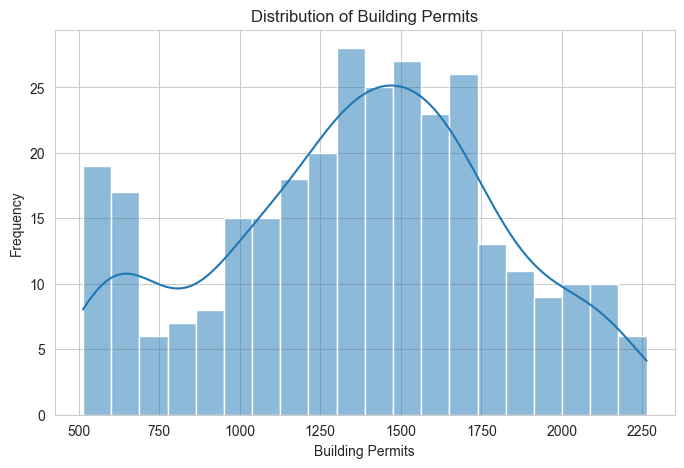

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["permits"], bins=20, kde=True)

plt.title("Distribution of Building Permits")
plt.xlabel("Building Permits")
plt.ylabel("Frequency")

plt.show()

The distribution of building permits is relatively moderately spread across the sample period, with most observations concentrated between about 1,000 and 1,700 permits. The distribution peaks around 1,400 to 1,600 permits, suggesting that moderate levels of permitting activity were the most common during the sample period.

Lower levels of building permits occurred less frequently than the moderates, however was distinctly peaked between about 500 and 700. This may reflect economic recession or even reduced housing demand. Higher levels of permits were  relatively uncommon, indicating that periods of strong construction and housing plan activity are relatively rare throughout the sample period.


## Trends Over Time

Because the data consists of monthly economic observations, it is important to examine how interest rates and housing market activity changes over time. Time series visuals can help identify economic trends and cycles.

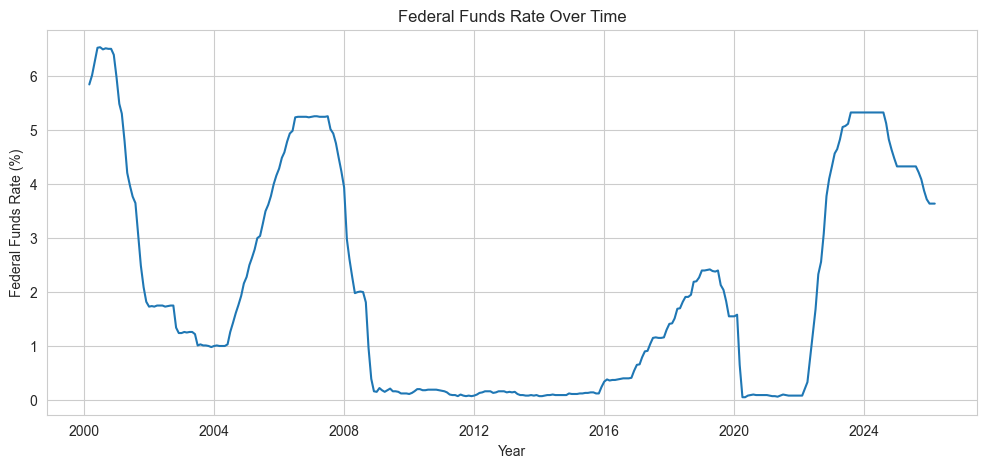

In [12]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["rate"])

plt.title("Federal Funds Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Federal Funds Rate (%)")

plt.show()


The Federal Funds Rate changed at considereable levels over the sample period. This reflects major shifts in economic conditions and monetary policy in the U.S. Interest rates were relatively high in the early 2000s before declining sharply during the 2008 financial crisis. Following the crisis, rates remained near zero for many years before increasing again after 2022 in response to rising inflation. Overall, the graph shows massive variation in interest rates across different economic periods.

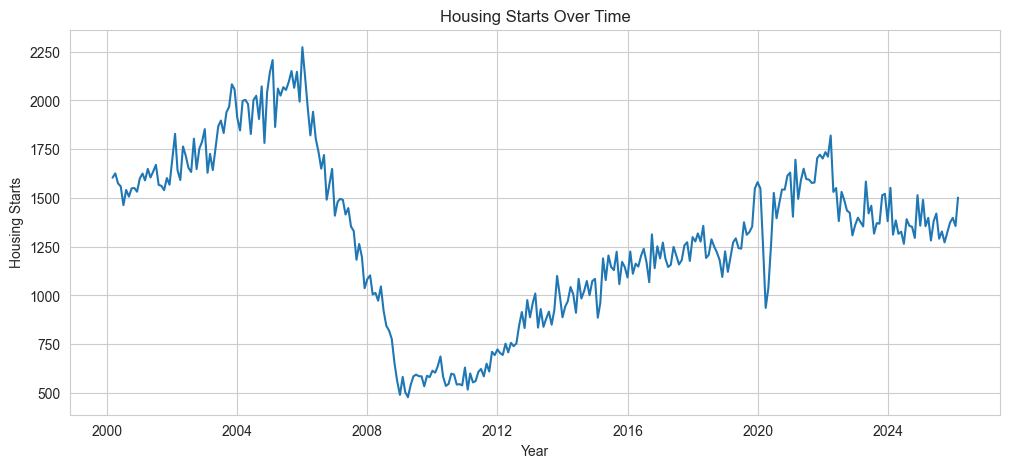

In [13]:
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["housing"])

plt.title("Housing Starts Over Time")
plt.xlabel("Year")
plt.ylabel("Housing Starts")

plt.show()

The housing starts time series plot shows considerable fluctuation over our sample period. Construction activity increased during the early 2000s before declining sharply during the 2008 financial crisis. Following the recession, housing starts gradually recovered over time. A noticeable decline also occurred during the COVID-19 pandemic in 2020, followed by a rapid recovery semi stabilization. Overall, the graph suggests that housing market activity is strongly influenced by broader economic conditions and economic cycles.

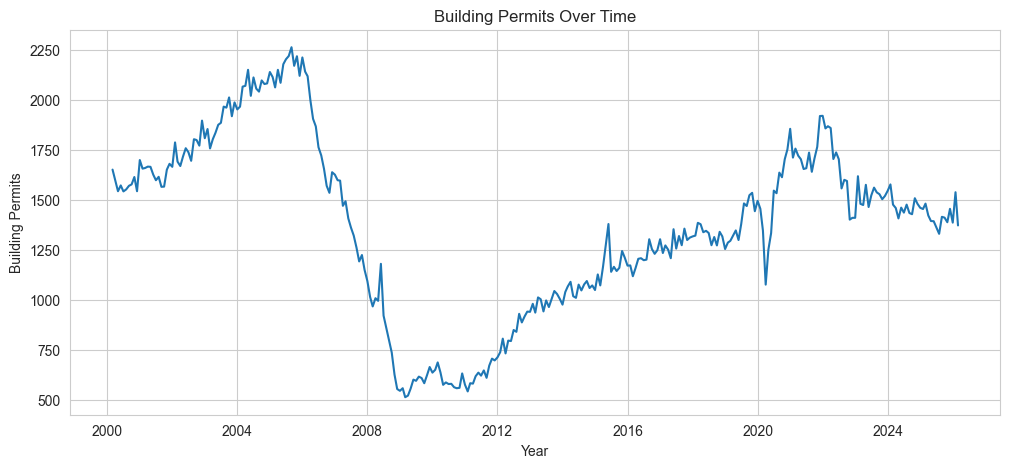

In [14]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["permits"])

plt.title("Building Permits Over Time")
plt.xlabel("Year")
plt.ylabel("Building Permits")

plt.show()

Building permits showed a trend similar to the housing starts time series for the sample period. Permit activity increased during the early 2000s before declining sharply during the 2008 financial crisis. Following the recession, where building permits gradually recovered over time. The same noticeable decline and recovery also occurred during the COVID-19 pandemic. Because building permits are often issued before construction begins, these trends may reflect changing expectations about future housing demand and economic conditions from builders.

## Comparing Interest Rates and Housing Market Activity

After examining each variable individually, the next step was to explore how interest rates and housing market activity may move together over time. The following visualizations compare the Federal Funds Rate with housing starts and building permits.

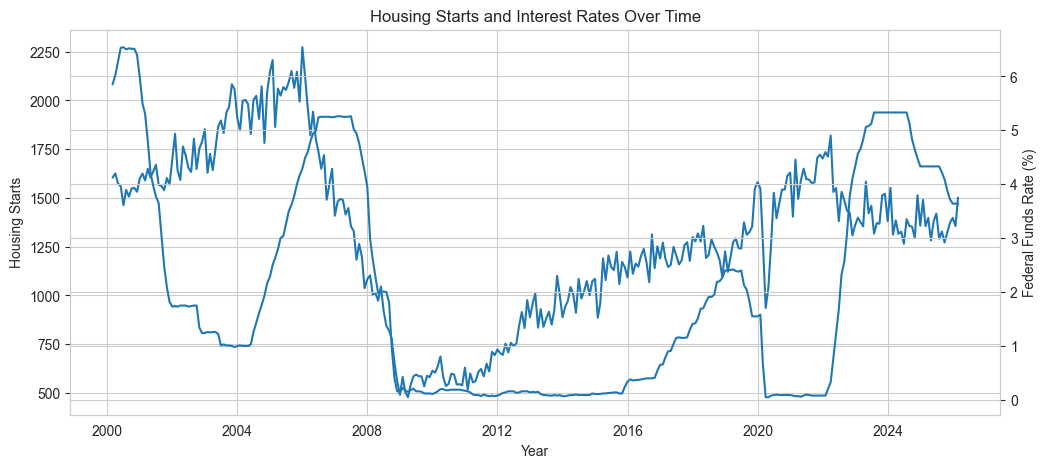

In [15]:
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(df["date"], df["housing"])
ax1.set_xlabel("Year")
ax1.set_ylabel("Housing Starts")
ax2 = ax1.twinx()
ax2.plot(df["date"], df["rate"])
ax2.set_ylabel("Federal Funds Rate (%)")

plt.title("Housing Starts and Interest Rates Over Time")

plt.show()

The combined time series graph shows that interest rates and housing starts don't always move together in a simple way. During some periods, declining interest rates are followed by increases in housing activity, while in other periods housing starts remained relatively strong despite rising interest rates. For example, housing starts declined sharply during the 2008 financial crisis even as interest rates were reduced substantially. More recently, housing activity remained relatively high during periods of rising interest rates after around 2022. Overall, the graph suggests that housing market activity is influenced by multiple economic factors rather than interest rates alone.

## Scatterplot Analysis

Scatterplots can help visualize whether there is a relationship that exists between interest rates and housing market activity.

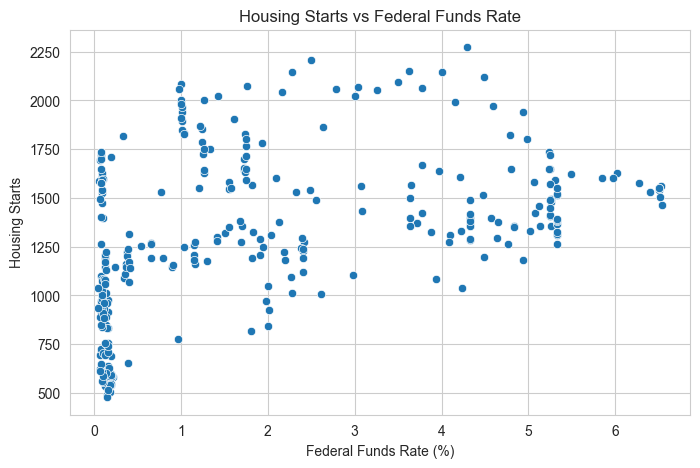

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="rate", y="housing", data=df)

plt.title("Housing Starts vs Federal Funds Rate")
plt.xlabel("Federal Funds Rate (%)")
plt.ylabel("Housing Starts")

plt.show()

The scatterplot shows that there is a large amount of variation in housing starts across interest rate levels. While some lower housing activity appears during periods of very low interest rates, and higher levels of housing starts are observed across a wide range of interest rates. The relationship between interest rates and housing starts does not appear linear and appears random. The scatterplot suggests that housing market activity is influenced by multiple economic factors in addition to interest rates alone.

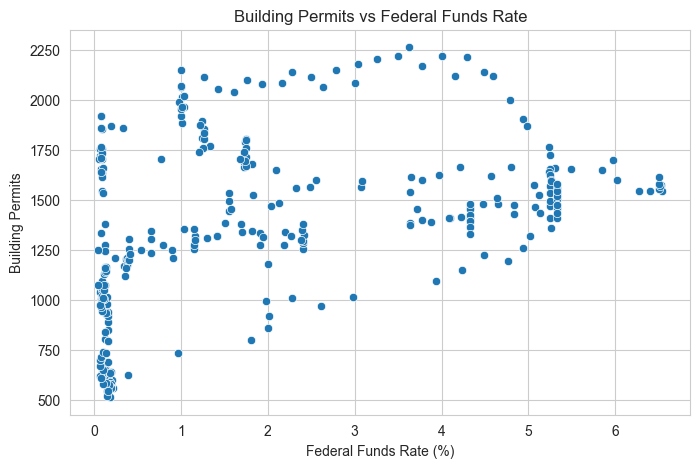

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="rate", y="permits", data=df)

plt.title("Building Permits vs Federal Funds Rate")
plt.xlabel("Federal Funds Rate (%)")
plt.ylabel("Building Permits")

plt.show()

The scatterplot between building permits and interest rates also shows that there is a large amount of variation across interest rate levels. Higher levels of permit activity appears across a large range of interest rates, while lower permit levels are concentrated more heavily during periods of very low rates. Overall, The relationship between interest rates and building permits does not appear linear and appears random. The scatterplot suggests that housing permit activity is influenced by multiple economic factors in addition to interest rates alone.

## Correlation Analysis

A correlation table was used to create a description of the strength and direction of the relationships between interest rates, housing starts, and building permits.

In [18]:
corr = df[["rate", "housing", "permits"]].corr()

corr

,rate,housing,permits
rate,1.000000,0.443987,0.429131
housing,0.443987,1.000000,0.983595
permits,0.429131,0.983595,1.000000


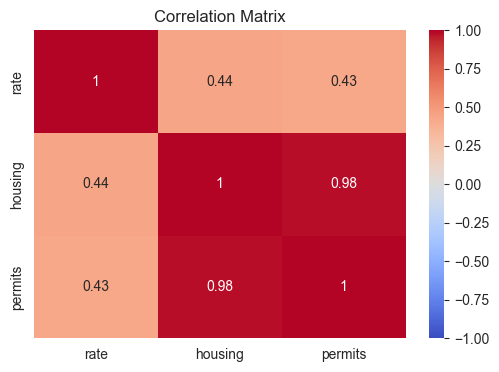

In [19]:
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

The correlation table shows a very strong and positive correlation between housing starts and building permits at 0.98. This is expected because both variables are closely related aspects of housing market activity.

Interest rates also show moderate and positive correlation with both housing starts at 0.44 and building permits at 0.43. This positive coorelation was somehwhat unexpected, as higher interest rates is associated with lower housing market activity. This suggests that the relationship between interest rates and housing market activity is more complicated than initially expected. Broader economic conditions such as economic growth periods, inflation, or demand can influence both interest rates and the housing market at the same time. 

## Comparing High and Low Interest Rate Periods

To better explore the relationship between interest rates and the housing market, the Fed Funds Rate was divided into higher rate and lower rate periods and it used the median interest rate as the seperation point. This grouping allows housing activity to be compared across different interest rates. 

In [20]:
median_rate = df["rate"].median()

median_rate

np.float64(1.26)

In [21]:
df["rate_group"] = np.where(df["rate"] > median_rate, "Higher Rate Period", "Lower Rate Period")
df[["rate", "rate_group"]].head()

,rate,rate_group
0,5.85,Higher Rate Period
1,6.02,Higher Rate Period
2,6.27,Higher Rate Period
3,6.53,Higher Rate Period
4,6.54,Higher Rate Period


In [22]:
df.groupby("rate_group")[["housing", "permits"]].mean()

,housing,permits
rate_group,,
Higher Rate Period,1497.864516,1559.122581
Lower Rate Period,1118.544304,1178.658228


Text(0, 0.5, 'Housing Starts')

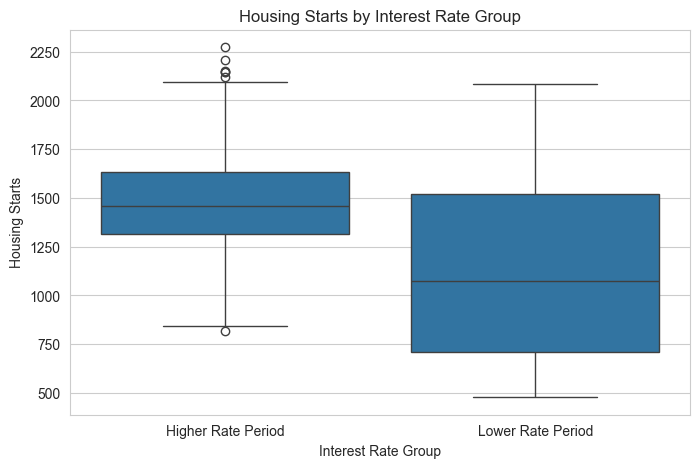

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(x="rate_group", y="housing", data=df)
plt.title("Housing Starts by Interest Rate Group")
plt.xlabel("Interest Rate Group")
plt.ylabel("Housing Starts")

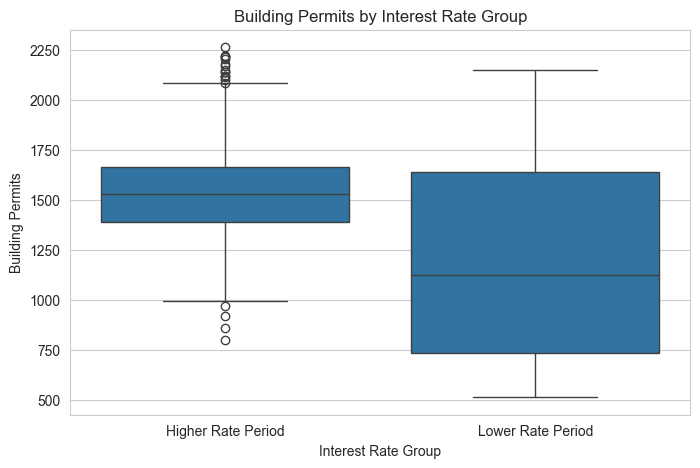

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(x="rate_group", y="permits", data=df)
plt.title("Building Permits by Interest Rate Group")
plt.xlabel("Interest Rate Group")
plt.ylabel("Building Permits")

plt.show()

The grouped averages show differences in housing market activity between high rate and low rate periods. Both housing starts and building permits were higher on average during the high rate periods. Average housing starts were approximately 1498 during high rate periods where it was about 1119 during low rate periods. Building permits showed a similar pattern. These findings support the idea that broader economic conditions are influence interest rates and housing market activity at the same time.

The boxplots also suggest that housing starts and building permits were generally higher during high rate periods, even though there is large varition in both groups. The boxplots also supports the idea that broader economic conditions may have influenced interest rates and housing market activity.

## Regression Analysis

Linear regression was used to better understand the relationship between interest rates and housing market activity. Regression analysis will help estimate how housing starts and building permits change as interest rates change.

### Regression Model: Housing Starts

In [25]:
import statsmodels.api as sm


X = df["rate"]
y = df["housing"]
X = sm.add_constant(X)

housing_model = sm.OLS(y, X).fit()

print(housing_model.summary())

                            OLS Regression Results                            
Dep. Variable:                housing   R-squared:                       0.197
Model:                            OLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     76.36
Date:                Sun, 10 May 2026   Prob (F-statistic):           1.50e-16
Time:                        16:02:30   Log-Likelihood:                -2301.5
No. Observations:                 313   AIC:                             4607.
Df Residuals:                     311   BIC:                             4615.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1120.2098     30.212     37.078      0.0

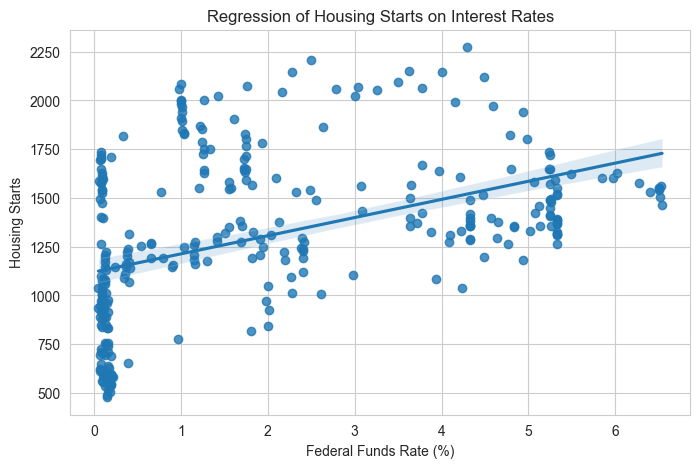

In [26]:
plt.figure(figsize=(8,5))

sns.regplot(x="rate",y="housing",data=df)

plt.title("Regression of Housing Starts on Interest Rates")
plt.xlabel("Federal Funds Rate (%)")
plt.ylabel("Housing Starts")

plt.show()

The regression results suggest there is a positive relationship between the interest rates and housing starts over our sample period. The estimated slope coefficient shows that for every one percent increase of the Fed Funds Rate, there is an increase of about 93 housing starts.

The p value for the IR coefficient was less than 0.001, which provides evidence against the null hypothesis that there is no relationship between interest rates and housing starts. This suggests that the observed relationship is statistically significant.

The model produced an R squared value of approximately 0.20, meaning that interest rates explain about 20% of the variation in housing starts. This implies that while interest rates are related to housing activity, most of the variation is better explained by other economic factors not included in the model.

In [27]:

X2 = df["rate"]
y2 = df["permits"]
X2 = sm.add_constant(X2)

permit_model = sm.OLS(y2, X2).fit()

print(permit_model.summary())

                            OLS Regression Results                            
Dep. Variable:                permits   R-squared:                       0.184
Model:                            OLS   Adj. R-squared:                  0.182
Method:                 Least Squares   F-statistic:                     70.20
Date:                Sun, 10 May 2026   Prob (F-statistic):           1.87e-15
Time:                        16:02:31   Log-Likelihood:                -2314.7
No. Observations:                 313   AIC:                             4633.
Df Residuals:                     311   BIC:                             4641.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1180.8746     31.512     37.473      0.0

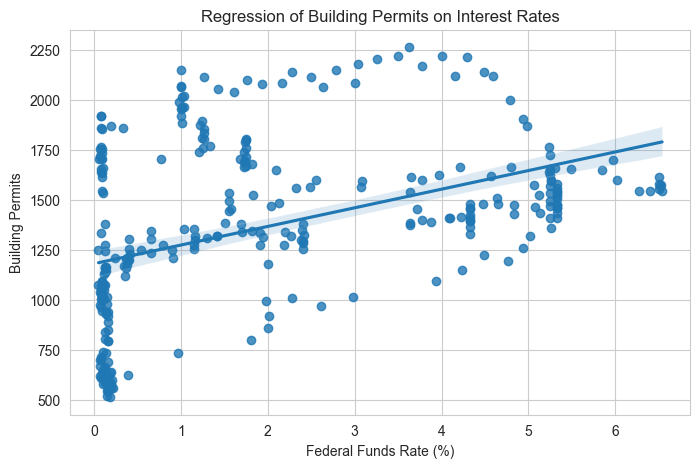

In [28]:
plt.figure(figsize=(8,5))

sns.regplot(x="rate", y="permits", data=df)

plt.title("Regression of Building Permits on Interest Rates")
plt.xlabel("Federal Funds Rate (%)")
plt.ylabel("Building Permits")

plt.show()

The regression results suggest there is a positive relationship between interest rates and building permits over our sample period. The estimated slope coefficient shows that for every one percent increase of the Fed Funds Rate, there is an increase of about 93 building permits.

The p value for the IR coefficient was less than 0.001, which provides evidence against the null hypothesis that there is no relationship between interest rates and building permits. This suggests that the observed relationship is statistically significant.

The model produced an R squared value of approximately 0.18, meaning that interest rates explain about 18% of the variation in building permits. This implies that while interest rates are related to housing activity, most of the variation is better explained by other economic factors not included in the model.

Because the p value is less than 0.05, we can reject the null hypothesis that there is no relationship between interest rates and housing market activity.

## Limitations

This analysis has multiple limitations. The first limitiation is that we only examine the relationship between interest rates and housing market activity using just 3 variables. There are many other economic factors, such as inflation, unemployment, income, supply/demand, and risk/confidence that might also influence housing starts and building permits. Also, the data consists of time series observations, which means the observations are not fully independent across time. This means the results should not be viewed as proof for causation.

## Conclusion

This project examined the relationship between interest rates and housing market activity in the United States using the Federal Funds Rate, housing starts, and building permits data from FRED.

Our EDA, visualizations, correlations, and regression models all suggests a positive relationship between interest rates and housing market activity over time. Both regression models produced results that are statistically significant, but our low R squared values show that interest rates can only explain part of the variablility in housing activity. Our findings suggest that the relationship between interest rates and housing market activity is more complicated than I originally expected. Broader economic conditions is what is most likley affecting this.